# Application: Special Functions in the Complex Plane

Visualize classical special functions to understand their analytic structure.

**Prerequisites**: Notebooks #1, #6 | **Time**: ~25 min

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import complexplorer as cp
from scipy.special import gamma, zeta, jv, ellipj

## Why Special Functions?

Special functions arise throughout mathematics and physics:
- **Gamma function**: Generalizes factorials
- **Zeta function**: Number theory, prime distribution
- **Bessel functions**: Wave equations, cylindrical symmetry
- **Elliptic functions**: Doubly periodic, algebraic curves

Complex visualization reveals their **analytic structure**!

## 1. Gamma Function

**Definition**: $\Gamma(z) = \int_0^\infty t^{z-1} e^{-t} dt$

**Properties**:
- $\Gamma(n) = (n-1)!$ for positive integers
- Poles at $z = 0, -1, -2, -3, \ldots$
- Functional equation: $\Gamma(z+1) = z\Gamma(z)$

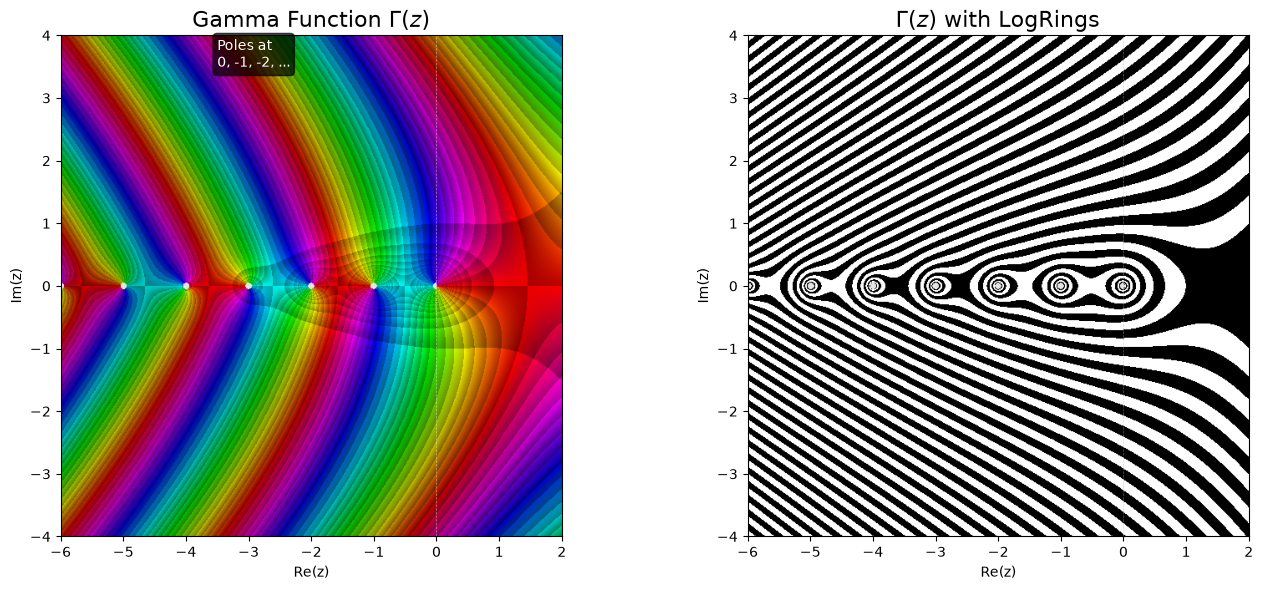


✓ Notice the simple poles along the negative real axis!
  Each pole corresponds to Γ(-n) for n = 0, 1, 2, ...


In [2]:
# Gamma function
def gamma_safe(z):
    """Gamma function with pole handling."""
    # Avoid exact poles at non-positive integers
    mask = (np.abs(z - np.round(z.real)) < 0.05) & (z.real <= 0)
    result = gamma(z)
    result[mask] = np.nan
    return result

domain = cp.Rectangle(re_length=8, im_length=8, center=-2+0j)
cmap = cp.Phase(phase_sectors=12, auto_scale_r=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Standard phase portrait
cp.plot(domain, gamma_safe, cmap=cmap, ax=ax1, resolution=600)
ax1.set_title(r"Gamma Function $\Gamma(z)$", fontsize=16)
ax1.axvline(x=0, color='white', linestyle='--', alpha=0.5, linewidth=0.5)
ax1.text(-3.5, 3.5, "Poles at\n0, -1, -2, ...", color='white', fontsize=10,
         bbox=dict(boxstyle='round', facecolor='black', alpha=0.7))

# LogRings to see modulus structure
cmap_log = cp.LogRings(log_spacing=0.3)
cp.plot(domain, gamma_safe, cmap=cmap_log, ax=ax2, resolution=600)
ax2.set_title(r"$\Gamma(z)$ with LogRings", fontsize=16)
ax2.axvline(x=0, color='cyan', linestyle='--', alpha=0.5, linewidth=0.5)

plt.tight_layout()
plt.show()

print("\n✓ Notice the simple poles along the negative real axis!")
print("  Each pole corresponds to Γ(-n) for n = 0, 1, 2, ...")

## 2. Riemann Zeta Function

**Definition**: $\zeta(z) = \sum_{n=1}^\infty n^{-z}$ (for $\text{Re}(z) > 1$)

**Properties**:
- Simple pole at $z = 1$
- Trivial zeros at $z = -2, -4, -6, \ldots$
- **Non-trivial zeros** on critical line $\text{Re}(z) = 1/2$ (Riemann Hypothesis!)
- Functional equation relates $\zeta(z)$ to $\zeta(1-z)$

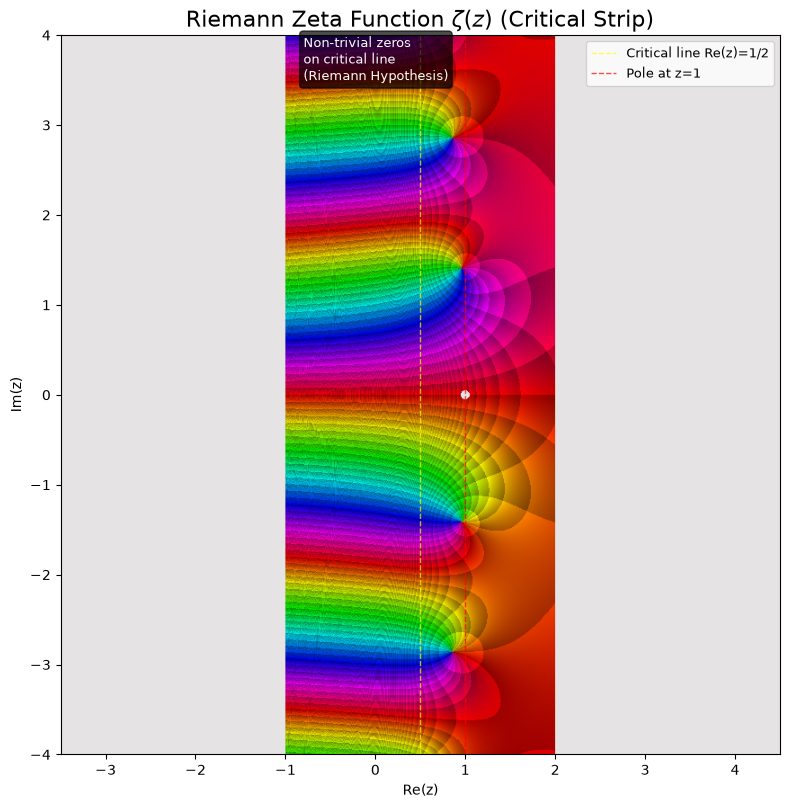


✓ The critical strip (0 < Re(z) < 1) is where the action happens!
  Riemann Hypothesis: All non-trivial zeros lie on Re(z) = 1/2


In [3]:
# Riemann zeta function
def zeta_safe(z):
    """Zeta function with pole handling at z=1."""
    # Avoid pole at z = 1
    mask = np.abs(z - 1) < 0.05
    result = np.zeros_like(z, dtype=complex)
    
    # Use scipy's zeta (real-valued, so we evaluate on grid)
    # For complex zeta, use mpmath or implement series
    # Here we use a simple approximation for demonstration
    safe_z = z.copy()
    safe_z[mask] = np.nan
    
    # Approximate zeta using scipy (limited to real part)
    # For better accuracy, use mpmath.zeta
    try:
        from mpmath import zeta as mp_zeta
        result = np.vectorize(lambda x: complex(mp_zeta(x)))(safe_z)
    except ImportError:
        # Fallback: simple series approximation
        result = np.sum([n**(-safe_z) for n in range(1, 50)], axis=0)
    
    result[mask] = np.nan
    return result

# Focus on critical strip
domain_strip = cp.Rectangle(re_length=3, im_length=8, center=0.5+0j)
cmap = cp.Phase(phase_sectors=12, auto_scale_r=True)

fig, ax = plt.subplots(1, 1, figsize=(8, 10))

cp.plot(domain_strip, zeta_safe, cmap=cmap, ax=ax, resolution=800)
ax.set_title(r"Riemann Zeta Function $\zeta(z)$ (Critical Strip)", fontsize=16)
ax.axvline(x=0.5, color='yellow', linestyle='--', alpha=0.7, linewidth=1, 
           label='Critical line Re(z)=1/2')
ax.axvline(x=1, color='red', linestyle='--', alpha=0.7, linewidth=1,
           label='Pole at z=1')
ax.legend(loc='upper right', fontsize=9)
ax.text(-0.8, 3.5, "Non-trivial zeros\non critical line\n(Riemann Hypothesis)", 
        color='white', fontsize=9,
        bbox=dict(boxstyle='round', facecolor='black', alpha=0.7))

plt.tight_layout()
plt.show()

print("\n✓ The critical strip (0 < Re(z) < 1) is where the action happens!")
print("  Riemann Hypothesis: All non-trivial zeros lie on Re(z) = 1/2")

## 3. Bessel Functions

**Definition**: Solutions to Bessel's differential equation
$$z^2 \frac{d^2w}{dz^2} + z\frac{dw}{dz} + (z^2 - n^2)w = 0$$

**Properties**:
- $J_n(z)$: Bessel function of first kind, order $n$
- Entire functions (no poles in ℂ)
- Infinitely many zeros on real axis
- Used in wave equations, heat transfer, quantum mechanics

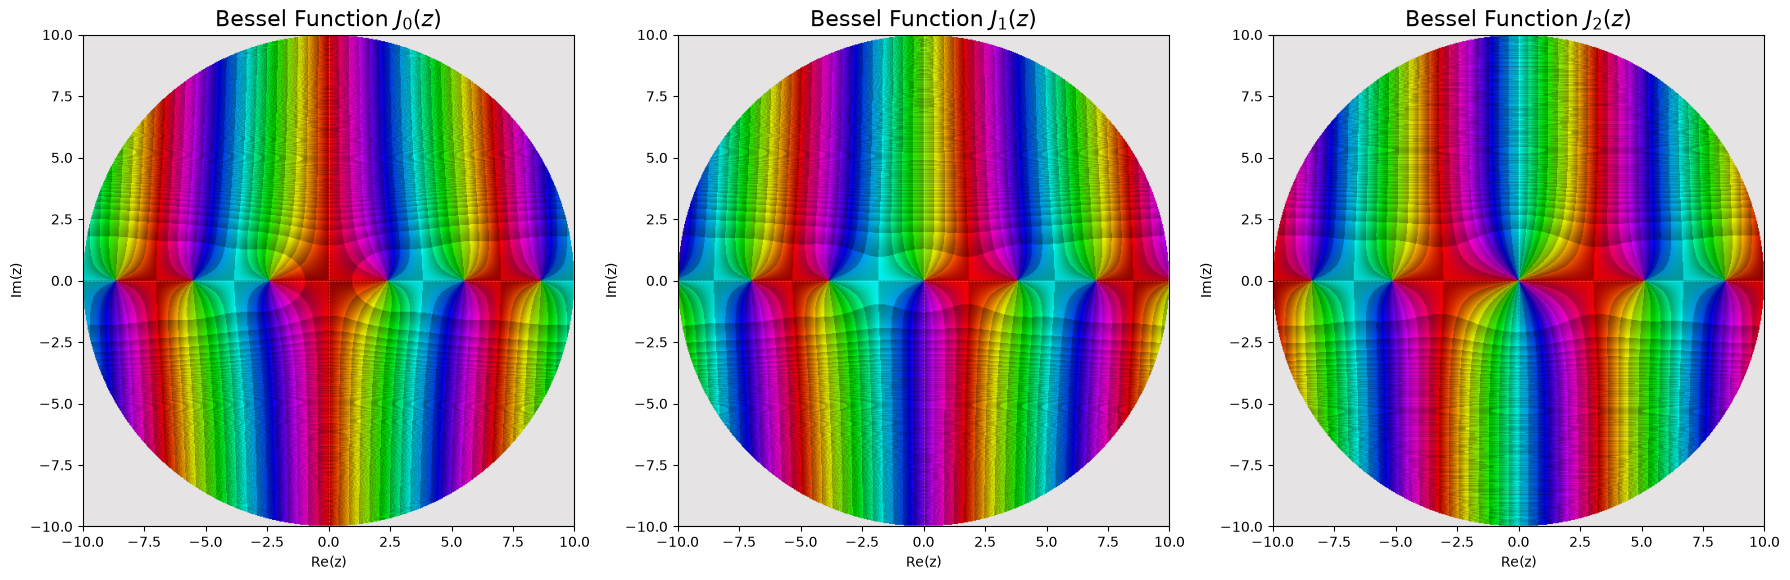


✓ Bessel functions are entire (analytic everywhere)!
  Notice the oscillatory behavior along the real axis
  and the increasing modulus away from the origin


In [4]:
# Bessel functions J_n(z)
def bessel_j0(z):
    """Bessel J_0 function."""
    return jv(0, z)

def bessel_j1(z):
    """Bessel J_1 function."""
    return jv(1, z)

def bessel_j2(z):
    """Bessel J_2 function."""
    return jv(2, z)

domain_bessel = cp.Disk(radius=10)
cmap = cp.Phase(phase_sectors=8, auto_scale_r=True)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, (func, name) in enumerate([(bessel_j0, r'$J_0(z)$'),
                                      (bessel_j1, r'$J_1(z)$'),
                                      (bessel_j2, r'$J_2(z)$')]):
    cp.plot(domain_bessel, func, cmap=cmap, ax=axes[idx], resolution=600)
    axes[idx].set_title(f"Bessel Function {name}", fontsize=16)
    
    # Mark some zeros on real axis
    axes[idx].axhline(y=0, color='white', linestyle='--', alpha=0.3, linewidth=0.5)
    axes[idx].axvline(x=0, color='white', linestyle='--', alpha=0.3, linewidth=0.5)

plt.tight_layout()
plt.show()

print("\n✓ Bessel functions are entire (analytic everywhere)!")
print("  Notice the oscillatory behavior along the real axis")
print("  and the increasing modulus away from the origin")

## 4. Elliptic Functions (Preview)

**Weierstrass ℘-function**: Doubly periodic meromorphic function

$$\wp(z) = \frac{1}{z^2} + \sum_{\omega \in \Lambda \setminus \{0\}} \left[ \frac{1}{(z-\omega)^2} - \frac{1}{\omega^2} \right]$$

where $\Lambda = \{m\omega_1 + n\omega_2 : m,n \in \mathbb{Z}\}$ is the period lattice.

**Properties**:
- Periodic: $\wp(z + \omega) = \wp(z)$ for all $\omega \in \Lambda$
- Poles of order 2 at lattice points
- Related to elliptic curves: $y^2 = 4x^3 - g_2 x - g_3$

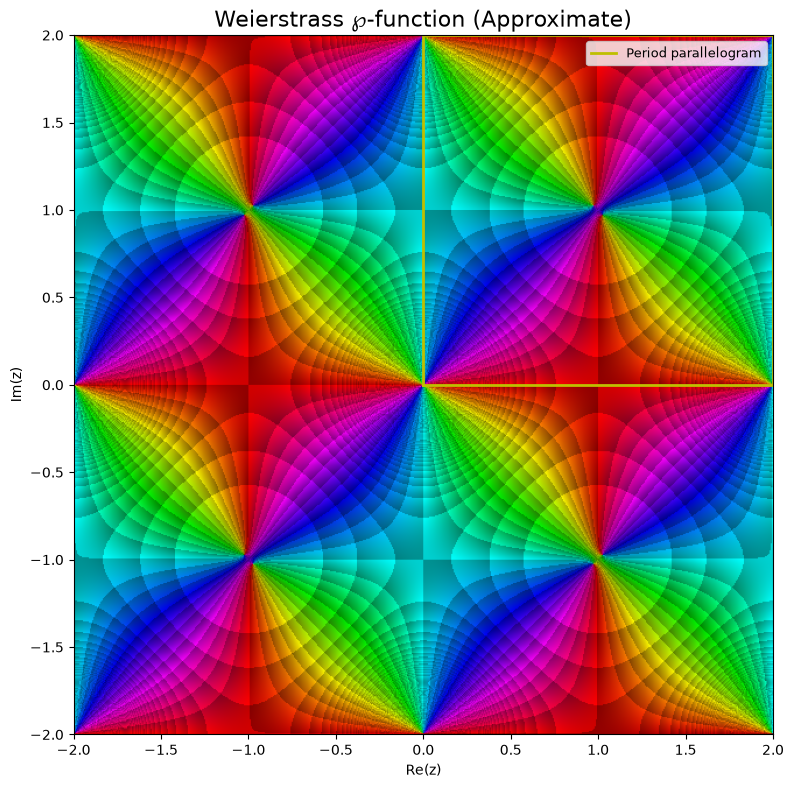


✓ Elliptic functions are doubly periodic!
  Pattern repeats in a lattice structure
  For accurate computation, use mpmath library


In [5]:
# Simplified elliptic function visualization
# Full implementation requires mpmath or specialized library

def weierstrass_approx(z, omega1=2, omega2=2j, terms=5):
    """Approximate Weierstrass ℘-function (finite sum).
    
    WARNING: This is a rough approximation for visualization only!
    Use mpmath.ellipfun('p', z, tau) for accurate computation.
    """
    result = 1 / (z**2 + 1e-10)  # Regularize pole at origin
    
    # Sum over lattice (finite approximation)
    for m in range(-terms, terms+1):
        for n in range(-terms, terms+1):
            if m == 0 and n == 0:
                continue
            omega = m * omega1 + n * omega2
            result += 1/(z - omega + 1e-10)**2 - 1/omega**2
    
    return result

# Show one period parallelogram
domain_elliptic = cp.Rectangle(re_length=4, im_length=4)
cmap = cp.Phase(phase_sectors=12, auto_scale_r=True)

fig, ax = plt.subplots(1, 1, figsize=(8, 8))

cp.plot(domain_elliptic, weierstrass_approx, cmap=cmap, ax=ax, resolution=600)
ax.set_title(r"Weierstrass $\wp$-function (Approximate)", fontsize=16)

# Draw period parallelogram
omega1, omega2 = 2, 2j
corners = [0, omega1, omega1+omega2, omega2, 0]
corners_x = [c.real for c in corners]
corners_y = [c.imag for c in corners]
ax.plot(corners_x, corners_y, 'y-', linewidth=2, label='Period parallelogram')
ax.legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.show()

print("\n✓ Elliptic functions are doubly periodic!")
print("  Pattern repeats in a lattice structure")
print("  For accurate computation, use mpmath library")

## Singularity Classification

Special functions exhibit different types of singularities:

### Poles (Meromorphic)
- **Gamma**: Simple poles at $z = 0, -1, -2, \ldots$
- **Zeta**: Simple pole at $z = 1$
- **Weierstrass ℘**: Double poles at lattice points

### Zeros
- **Bessel $J_n$**: Infinitely many zeros on ℝ
- **Zeta**: Trivial zeros at $z = -2, -4, -6, \ldots$
- **Zeta**: Non-trivial zeros in critical strip

### Entire Functions
- **Bessel $J_n$**: No poles (analytic everywhere in ℂ)

### Branch Cuts
- Not shown here, but see: $\sqrt{z}$, $\log z$ (choose branch)

### Essential Singularities
- **Example**: $e^{1/z}$ at $z = 0$ (wild behavior, see Notebook #6)

## Pedagogical Value

Visualizing special functions teaches:

1. **Analytic continuation**: Functions extend beyond their series definition
2. **Singularity structure**: Poles, zeros, branch cuts
3. **Symmetry**: Functional equations become geometric
4. **Periodicity**: Tiling patterns (elliptic functions)
5. **Modulus behavior**: Growth rates at infinity

**Complex analysis reveals what real-valued plots cannot!**

## Further Exploration

### Other Special Functions
- **Airy functions**: Ai(z), Bi(z)
- **Hypergeometric functions**: $_2F_1(a,b;c;z)$
- **Jacobi theta functions**: $\theta_n(z, q)$
- **Polylogarithm**: $\text{Li}_s(z)$

### Libraries
- **scipy.special**: Basic special functions (real & complex)
- **mpmath**: Arbitrary precision special functions
- **sympy**: Symbolic computation

### Recommended Reading
- Abramowitz & Stegun: "Handbook of Mathematical Functions"
- NIST Digital Library of Mathematical Functions (dlmf.nist.gov)
- Whittaker & Watson: "A Course of Modern Analysis"

## Summary

✅ Gamma function: Simple poles at non-positive integers
✅ Zeta function: Pole at z=1, zeros in critical strip
✅ Bessel functions: Entire functions with oscillatory behavior
✅ Elliptic functions: Doubly periodic with lattice of poles
✅ Singularity classification: Poles, zeros, essential singularities

## Mathematical Context

Special functions are not just computational tools - they are fundamental objects in:
- **Number theory**: Riemann zeta and primes
- **Physics**: Wave equations, quantum mechanics
- **Geometry**: Elliptic curves, modular forms
- **Analysis**: Analytic continuation, functional equations

Complex visualization makes their structure transparent! 🎨📐